# v4 — Unified Model Comparison with 7–15 km Annulus Pseudo-Absence Sampling

**Thesis:** Spatial Assessment of Wildfire Susceptibility and Socio-Ecological Exposure,
Sabanas del Yarí–Bajo Caguán Deforestation Nucleus, Colombian Amazon
**Author:** Natalia Ríos Galeano · UCL MSc Geospatial Sciences and Computing
**Version:** `tuning/v4/v4_buffer_7_15km`

---

## 1 · What this version does, and why it exists

Previous versions (`v1`–`v3` for LR/RF, plus XGBoost `v1`–`v2`) varied the presence : pseudo-absence
ratio (1:1, 2:1, 3:1) while holding the **exclusion buffer fixed at 3 km**. This version changes the
sampling geometry instead and added a stratified sampling within a 1:1 ratio to train the model with equal spatio and temporal non absences, and holds everything else constant so the three algorithms are compared
on genuinely identical footing.

### The problem v4 addresses

Two diagnostics from the previous round motivate this re-sampling:

1. **The Moran's I correlogram never flattened inside 3 km.** Global Moran's I on the target was
   `+0.329 (p = 0.001)`, and by distance band it decayed only slowly:

   | Band | 1 km | 2 km | 3 km | 5 km | 7.5 km | 10 km | 15 km |
   |---|---|---|---|---|---|---|---|
   | Moran's I | +0.460 | +0.459 | **+0.407** | +0.419 | +0.354 | +0.332 | +0.324 |

   At the 3 km buffer used in `v1`–`v3`, residual spatial dependence was still strong (**I ≈ 0.41**).
   Pseudo-absences drawn immediately outside that ring were therefore still inside the presences'
   zone of autocorrelation, which inflates apparent spatial-CV performance and — more importantly —
   compresses the *between-class* contrast in spatially smooth predictors.

2. **Static anthropogenic predictors under-performed.** SHAP ranked `dist_roads`, `dist_mosaic` and
   `dist_coca` below fuel and fire-weather variables, contrary to the Colombian-Amazon literature.
   A leading candidate explanation is that a 3 km buffer draws non-fire points from the *same
   near-field envelope* as the fire points, so both classes share near-identical distance-to-road
   and distance-to-mosaic distributions and the model has nothing to separate on.

### The v4 design response

## Pseudo-Absence Sampling Strategy

Because fire occurrence is recorded only as presences (burned pixels), the model
requires **pseudo-absences** — locations treated as "non-fire" — to learn what
distinguishes burnable from non-burnable conditions. How these are sampled is not a
minor preprocessing choice: it directly shapes what the model can and cannot learn.
This version (`v4`) uses a sampling design built on three deliberate decisions.

### 1 · Annulus geometry (7–15 km ring)

Pseudo-absences are drawn from a **ring** around each fire point — at least **7 km**
away (inner radius) and at most **15 km** away (outer radius) — rather than from a
simple "anywhere beyond 3 km" buffer.

- **Inner radius = 7 km.** The Moran's I correlogram showed strong spatial
  autocorrelation in fire occurrence that only levelled off around 7 km (I ≈ 0.35),
  still being ≈0.41 at the 3 km buffer used in earlier versions. Drawing absences
  from *inside* that autocorrelated zone means they are spatially near-identical to
  presences, which inflates cross-validation scores and suppresses the contrast the
  model needs. The 7 km inner radius places absences beyond the range of residual
  spatial dependence.

- **Outer radius = 15 km.** An upper bound keeps absences within the same
  environmental and socio-political setting as the presences. Without it, absences
  drift into systematically different terrain and the model learns to separate
  *regions* rather than *fire conditions* — producing optimistic metrics with no
  operational value. The annulus is therefore a compromise: **far enough to be
  statistically independent, close enough to remain a fair counterfactual.**

### 2 · Balanced ratio (1 : 1)

Equal numbers of presences and pseudo-absences are used. For classification and
machine-learning methods (Random Forest, XGBoost), a balanced design is the
recommended choice (Barbet-Massin et al., 2012), and it keeps the priority metric
(PR-AUC) directly interpretable and comparable across models, since its no-skill
baseline is fixed at 0.50. The model's output is used as a **relative susceptibility
ranking** — later reclassified into bins for the exposure and carbon overlays — not
as a calibrated probability, so the training ratio need not reproduce real-world
fire prevalence.

### 3 · Proportional stratification by year

Absences are sampled **proportionally to the annual distribution of presences**, so
that each year contributes pseudo-absences in the same proportion as it contributes
fires. Peak fire years (2004, 2007, 2018) receive proportionally more absences;
quiet years (2023, 2024) receive fewer, matching their presences exactly.

This matters because several predictors — the Oceanic Niño Index, temperature, and
VPD — vary **year to year**, taking near-identical values across all pixels within a
given year. If presences clustered in high-fire years while absences were spread
evenly across time, the model could separate the two classes by *year* — and hence
by that year's climate values — rather than by genuine fire conditions. That would
inflate performance and, worse, distort the interpretation of which drivers matter.
Stratifying by year removes this temporal confound: presences and pseudo-absences
share an identical year distribution, so the annual climate variables must earn
their importance through their relationship with fire *within* each year, not
through spurious correlation with high-fire years.

### Why the overall design is relevant

Together these three choices ensure the model is trained to answer the right
question — *what local conditions distinguish where fire occurs from where it does
not* — rather than an easier but useless proxy question (*which region is this?* or
*which year is this?*). This is what makes the resulting susceptibility surface, and
the feature-importance analysis built on top of it, defensible as evidence for
decision-making rather than an artefact of how the training data were assembled.

### What is carried over unchanged from `tuning/v3`

So that the buffer is the *only* thing that differs, the dataset cell reproduces v3 exactly in every
other respect:

| Element | Setting | Note |
|---|---|---|
| Base table | `pixel_year_full.csv` | identical to v3 |
| Ratio | **1 : 1** | see §2 |
| Seed | `42` | identical to v3 |
| Exclusion criterion | **per-year** | a pixel that burned in a *different* year may still serve as an absence — v3's convention |
| Absence draw | global, **unstratified** | v3's convention; year-balance is checked in §5 |
| Spatial blocks | `0.25°` grid | identical to v3 |
| Buffer | **7–15 km annulus** | ← the only change (v3: 3 km, no outer bound) |

> **Note on distance units.** Distances are computed in degrees and converted with
> `1° ≈ 111 km`. Across the nucleus (≈0.2–2.6 °N) the longitudinal error from ignoring the
> `cos(latitude)` term is under 0.1 %, so no correction is applied. Worth a methods footnote.

> **Out of scope for v4:** SHAP and other interpretability analyses are deliberately excluded here.
> This notebook establishes *which model on which dataset*; interpretation follows once that is settled.

---

## 2 · Why a 1 : 1 ratio

The ratio is fixed at 1:1 rather than treated as a tuning parameter, on three grounds:

1. **Methodological precedent.** Barbet-Massin et al. (2012), the foundational reference on
   pseudo-absence selection, find that for *classification and machine-learning* techniques
   (Random Forest, boosted trees) the best performance is obtained with **equal numbers of
   presences and pseudo-absences** — in contrast to regression-based methods, which benefit from a
   large absence pool. RF and XGBoost fall squarely in the first category.

2. **Comparability of PR-AUC.** PR-AUC is the priority metric here, given the rare-event nature of
   fire — but its no-skill baseline equals class prevalence (0.50 at 1:1, 0.33 at 2:1, 0.25 at 3:1).
   Comparing raw PR-AUC across ratios therefore compares numbers on different scales. Fixing the
   ratio makes PR-AUC directly interpretable and directly comparable across the three algorithms.

3. **The output is a relative ranking, not a calibrated probability.** The susceptibility surface is
   reclassified into bins (1–40, 41–60, 61–80, 81–100) for the exposure and carbon-at-risk overlays.
   What matters is the *ordering* of pixels by susceptibility, not the absolute probability, so the
   training ratio need not reproduce real-world fire prevalence.

Consistent with the dominant convention in the fire-susceptibility literature (Dahal et al. 2025;
Uthappa et al. 2025; and the majority of the 112 studies reviewed by Mihajlovski & Zhiyanski 2025),
balanced training sets are the norm for RF/XGBoost susceptibility mapping.


## 3 · Configuration

Only the settings **not** defined by the dataset cell live here — output location, the temporal split,
and CV settings. Sampling parameters (`INNER_BUFFER`, `OUTER_BUFFER`, `RATIO`, `SEED`, `BLOCK`,
`pred_cols`) are set in §4 so that cell stays a faithful copy of the v3 loader.

> **Path note.** Your message gave two locations — `tuning\v4_buffer_7km_15km` for the CSVs and
> `tuning/v4/v4_buffer_7_15km/` for the folder. This notebook uses the second; change `VERSION_DIR`
> if you prefer the first.

## 4 · Build the dataset (7–15 km annulus, ratio 1:1)

This is the `tuning/v3` loader with **one change**: the simple 3 km exclusion buffer is replaced by a
7–15 km ring. Everything else — base table, seed, per-year criterion, block grid, ratio — is identical,
so any difference in results is attributable to the buffer alone.

The cell prints an availability diagnostic. The annulus is far more restrictive than a one-sided
buffer (it discards points that are *too far* as well as *too close*), so if the eligible pool falls
below the number of presences required, the warning will say so explicitly rather than silently
under-filling the sample.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings, json, time
warnings.filterwarnings("ignore")

# ==== CARPETA DE SALIDA =====================================================
VERSION_DIR = Path(r"C:\Users\Natal\CEGE0049-Wildfire-Susceptibility-Assessment-in-Sabanas-de-Yar---Bajo-Cagu-n-Colombian-Amazon\tuning\v4\v4_buffer_7_15km")
VERSION_DIR.mkdir(parents=True, exist_ok=True)

# ==== SPLIT TEMPORAL (idéntico a v1-v3) ====================================
TRAIN_END_YEAR = 2019
TEST_START     = 2020
TEST_END       = 2024

# ==== VALIDACIÓN CRUZADA ESPACIAL ==========================================
N_SPATIAL_FOLDS = 5          # 5 folds sobre 71 bloques (10 degeneraba en folds de una sola clase)

# ==== NOMBRES DE COLUMNAS en model_df ======================================
LABEL_COL = "burned"
GROUP_COL = "block"
YEAR_COL  = "year"
LON_COL, LAT_COL = "lon", "lat"

print("Salida ->", VERSION_DIR)

Salida -> C:\Users\Natal\CEGE0049-Wildfire-Susceptibility-Assessment-in-Sabanas-de-Yar---Bajo-Cagu-n-Colombian-Amazon\tuning\v4\v4_buffer_7_15km


In [16]:
# === v4 — Setup: dataset ratio 1:1 con anillo de exclusión 7–15 km ===
# Reconstruye el mismo dataset 1:1 de tuning/v3 (misma tabla base pixel_year_full.csv,
# misma semilla random_state=42, mismo criterio por año), cambiando ÚNICAMENTE la
# geometría de muestreo de pseudo-ausencias: de un buffer simple de 3 km a un ANILLO
# de 7–15 km alrededor de los píxeles quemados.
#   - Radio interno 7 km  -> el correlograma de Moran's I se aplana (~0.35); rompe la
#                            dependencia espacial residual que el buffer de 3 km (I≈0.41) dejaba.
#   - Radio externo 15 km -> mantiene las ausencias dentro del mismo entorno ambiental
#                            y socio-político; sin este tope el modelo aprende a separar
#                            REGIONES en vez de CONDICIONES de fuego (métricas infladas).
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             confusion_matrix)
from sklearn.base import clone

PIXEL_YEAR_PATH = r"C:\Users\Natal\CEGE0049-Wildfire-Susceptibility-Assessment-in-Sabanas-de-Yar---Bajo-Cagu-n-Colombian-Amazon\data\model_dataset\pixel_year_full.csv"
pixel_year = pd.read_csv(PIXEL_YEAR_PATH) 
pred_cols = ['dist_roads','dist_parks','dist_coca','dist_mosaic',
             'temp_C','vpd_kPa','ndvi','wind_ms','oni']
BLOCK = 0.25
INNER_BUFFER = 7000           # v4: radio interno del anillo (antes EXCL_BUFFER = 3000)
OUTER_BUFFER = 15000          # v4: radio externo del anillo
inner_deg = INNER_BUFFER / 111000
outer_deg = OUTER_BUFFER / 111000
RATIO = 1                     # ratio ganador identificado en tuning/v3
SEED = 42
    
presences = pixel_year[pixel_year['burned'] == 1].copy()
absences_all = pixel_year[pixel_year['burned'] == 0].copy()

kept_absences, ring_diag = [], []
for y in sorted(pixel_year['year'].unique()):
    pres_y = presences[presences['year'] == y][['lon','lat']].values
    abs_y  = absences_all[absences_all['year'] == y]
    if len(pres_y) == 0:
        kept_absences.append(abs_y); continue
    tree = cKDTree(pres_y)
    dists, _ = tree.query(abs_y[['lon','lat']].values, k=1)
    in_ring = (dists >= inner_deg) & (dists <= outer_deg)
    kept_absences.append(abs_y[in_ring])
    ring_diag.append({'year': y, 'n_pres': len(pres_y), 'n_abs_year': len(abs_y),
                      'too_close': int((dists < inner_deg).sum()),
                      'too_far':   int((dists > outer_deg).sum()),
                      'in_ring':   int(in_ring.sum())})
absences_ring = pd.concat(kept_absences, ignore_index=True)

# --- diagnóstico de disponibilidad (el anillo es mucho más restrictivo que el buffer 3 km)
ring_diag = pd.DataFrame(ring_diag)
n_needed = int(round(RATIO * len(presences)))
print(f"Anillo {INNER_BUFFER/1000:.0f}–{OUTER_BUFFER/1000:.0f} km | "
      f"elegibles: {len(absences_ring):,} | requeridas: {n_needed:,}")
print(f"  excluidas por cercanía (< {INNER_BUFFER/1000:.0f} km): {ring_diag.too_close.sum():,}")
print(f"  excluidas por lejanía  (> {OUTER_BUFFER/1000:.0f} km): {ring_diag.too_far.sum():,}")
if len(absences_ring) < n_needed:
    print(f"  ⚠ POOL INSUFICIENTE: faltan {n_needed - len(absences_ring):,} pseudo-ausencias.")
    print("    Opciones: ampliar OUTER_BUFFER, o densificar el muestreo de píxeles no quemados.")

# Estratificación PROPORCIONAL por año, con relleno hasta 1:1 global ---
# El anillo 7–15 km no deja suficientes ausencias para exigir n_presencias por año,
# así que repartimos las ausencias DISPONIBLES respetando el peso anual de las
# presencias, y completamos el faltante con el resto del pool para conservar 1:1 global.
n_needed = int(round(RATIO * len(presences)))

# 1) Cuota objetivo por año = peso anual de las presencias, capada por disponibilidad
pres_by_year = presences['year'].value_counts()
target_by_year = (pres_by_year * RATIO).round().astype(int)
avail_by_year = absences_ring['year'].value_counts()

picks = []
for y, cuota in target_by_year.items():
    pool_y = absences_ring[absences_ring['year'] == y]
    take = min(cuota, len(pool_y))
    if take > 0:
        picks.append(pool_y.sample(n=take, random_state=SEED))
strat = pd.concat(picks, ignore_index=True) if picks else absences_ring.head(0)

# 2) Relleno: si la estratificación no alcanzó n_needed (por años cortos),
#    completar con ausencias restantes del pool (sin repetir) para mantener 1:1
faltan = n_needed - len(strat)
if faltan > 0:
    resto = absences_ring.loc[~absences_ring.index.isin(strat.index)]
    relleno = resto.sample(n=min(faltan, len(resto)), random_state=SEED)
    absences_sample = pd.concat([strat, relleno], ignore_index=True)
else:
    absences_sample = strat.sample(n=n_needed, random_state=SEED)

n_abs = len(absences_sample)
print(f"Estratificación proporcional -> {n_abs:,} ausencias "
      f"({len(strat):,} por cuota anual + {max(0,faltan):,} de relleno) | "
      f"objetivo 1:{RATIO} = {n_needed:,}")

model_df = pd.concat([presences, absences_sample], ignore_index=True) \
             .sample(frac=1, random_state=SEED).reset_index(drop=True)
model_df['block'] = (model_df['lon']//BLOCK).astype(int).astype(str) + '_' + \
                    (model_df['lat']//BLOCK).astype(int).astype(str)

n_pres = int(model_df['burned'].sum())
print("\nDataset v4 (anillo 7–15 km, ratio 1:1) ->", model_df.shape,
      f"({n_pres} presencias, {model_df.shape[0]-n_pres} pseudo-ausencias)")

Anillo 7–15 km | elegibles: 14,928 | requeridas: 2,077
  excluidas por cercanía (< 7 km): 9,522
  excluidas por lejanía  (> 15 km): 56,657
Estratificación proporcional -> 2,077 ausencias (2,077 por cuota anual + 0 de relleno) | objetivo 1:1 = 2,077

Dataset v4 (anillo 7–15 km, ratio 1:1) -> (4154, 14) (2077 presencias, 2077 pseudo-ausencias)


In [17]:
# ¿Qué años quedaron desbalanceados tras la estratificación?
chk = (model_df.groupby('year')['burned']
       .agg(presencias=lambda s: int((s==1).sum()),
            ausencias =lambda s: int((s==0).sum())))
chk['ratio_abs_pres'] = (chk.ausencias / chk.presencias).round(2)
print(chk)
print("\nAños con MENOS ausencias que presencias:",
      chk.index[chk.ausencias < chk.presencias].tolist())

      presencias  ausencias  ratio_abs_pres
year                                       
2001          55         55             1.0
2002          31         31             1.0
2003          42         42             1.0
2004         287        287             1.0
2005          27         27             1.0
2006          80         80             1.0
2007         296        296             1.0
2008          93         93             1.0
2009          56         56             1.0
2010          55         55             1.0
2011         126        126             1.0
2012          37         37             1.0
2013          61         61             1.0
2014         110        110             1.0
2015          28         28             1.0
2016          73         73             1.0
2017          56         56             1.0
2018         296        296             1.0
2019          19         19             1.0
2020          51         51             1.0
2021          25         25     

## 5 · Sampling diagnostics

Three checks that the sample is sound before any model sees it:

1. **Per-year eligibility** — how many candidate absences fell inside vs outside the ring each year.
   Years where `in_ring` collapses are years where the annulus struggled.
2. **Year balance** — the v3 loader draws absences *globally*, not stratified by year, so the absence
   year-distribution is not guaranteed to match the presence one. Because eligibility now varies by
   year with fire geography, this can drift more than it did in v3. If the two distributions diverge
   badly, the model can separate classes on *year* (and hence on the annual climate predictors)
   rather than on fire conditions — the cell flags this if it happens.
3. **Spatial arrangement** — absences should form a halo around the fire clusters: neither
   overlapping them, nor drifting to the edges of the frame.

Largest presence/absence year-share gap: 0.000 (year 2001)
  ✓ Year distributions are well matched; unstratified draw is safe here.


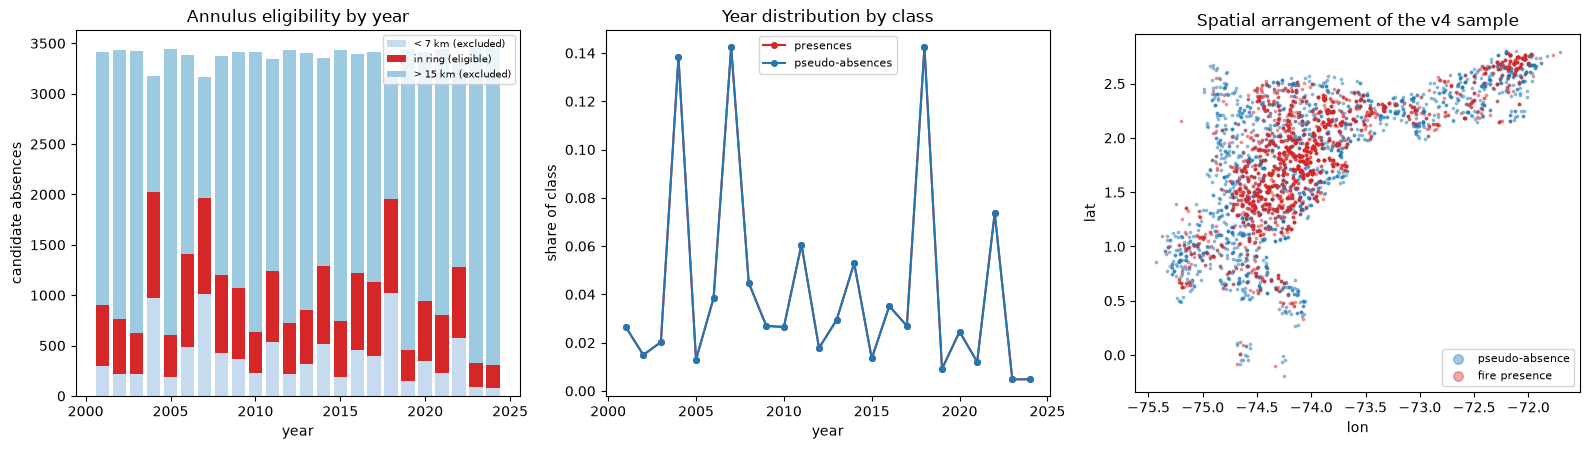

Saved: v4_ring_eligibility_by_year.csv | v4_year_balance_check.csv | v4_sampling_diagnostics.png


In [18]:
# --- 1. Per-year eligibility --------------------------------------------------
ring_diag_path = VERSION_DIR / "v4_ring_eligibility_by_year.csv"
ring_diag.to_csv(ring_diag_path, index=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

ax = axes[0]
ax.bar(ring_diag[YEAR_COL], ring_diag["too_close"], label=f"< {INNER_BUFFER/1000:.0f} km (excluded)",
       color="#c6dbef")
ax.bar(ring_diag[YEAR_COL], ring_diag["in_ring"], bottom=ring_diag["too_close"],
       label="in ring (eligible)", color="#d62728")
ax.bar(ring_diag[YEAR_COL], ring_diag["too_far"],
       bottom=ring_diag["too_close"] + ring_diag["in_ring"],
       label=f"> {OUTER_BUFFER/1000:.0f} km (excluded)", color="#9ecae1")
ax.set_xlabel("year"); ax.set_ylabel("candidate absences")
ax.set_title("Annulus eligibility by year"); ax.legend(fontsize=7)

# --- 2. Year balance, presences vs sampled absences ---------------------------
pres_yr = model_df[model_df[LABEL_COL] == 1][YEAR_COL].value_counts(normalize=True).sort_index()
abs_yr  = model_df[model_df[LABEL_COL] == 0][YEAR_COL].value_counts(normalize=True).sort_index()
bal = pd.DataFrame({"presence_share": pres_yr, "absence_share": abs_yr}).fillna(0)
bal["abs_diff"] = (bal.presence_share - bal.absence_share).abs()
bal.to_csv(VERSION_DIR / "v4_year_balance_check.csv")

ax = axes[1]
ax.plot(bal.index, bal.presence_share, marker="o", ms=4, label="presences", color="#d62728")
ax.plot(bal.index, bal.absence_share,  marker="o", ms=4, label="pseudo-absences", color="#1f77b4")
ax.set_xlabel("year"); ax.set_ylabel("share of class")
ax.set_title("Year distribution by class"); ax.legend(fontsize=8)

max_gap = bal.abs_diff.max()
worst_yr = bal.abs_diff.idxmax()
print(f"Largest presence/absence year-share gap: {max_gap:.3f} (year {worst_yr})")
if max_gap > 0.05:
    print("  ⚠ Year distributions diverge by >5 pp in at least one year.")
    print("    The models may separate classes partly on YEAR (via the annual climate")
    print("    predictors) rather than on fire conditions. Consider stratifying the")
    print("    absence draw by year and recording it as a deviation from v3.")
else:
    print("  ✓ Year distributions are well matched; unstratified draw is safe here.")

# --- 3. Spatial arrangement ---------------------------------------------------
ax = axes[2]
m0 = model_df[LABEL_COL] == 0
ax.scatter(model_df.loc[m0, LON_COL], model_df.loc[m0, LAT_COL], s=3, alpha=.4,
           label="pseudo-absence", color="#1f77b4")
ax.scatter(model_df.loc[~m0, LON_COL], model_df.loc[~m0, LAT_COL], s=3, alpha=.4,
           label="fire presence", color="#d62728")
ax.set_xlabel("lon"); ax.set_ylabel("lat")
ax.set_title("Spatial arrangement of the v4 sample")
ax.legend(markerscale=4, fontsize=8); ax.set_aspect("equal", adjustable="box")

fig.tight_layout()
fig.savefig(VERSION_DIR / "v4_sampling_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", ring_diag_path.name, "| v4_year_balance_check.csv | v4_sampling_diagnostics.png")

## 6 · Train / test split and spatial blocks

The dataset cell already built the `block` column on a 0.25° grid (identical to v3). Grouped CV keeps
whole blocks together, so no fold is validated on points from a block it trained on — this is what
makes the spatial metric an estimate of generalisation to *unseen locations* rather than an
interpolation score.

The temporal split is the v1–v3 convention: fit on ≤ 2019, evaluate on the untouched 2020–2024 years.

In [19]:
train_mask = model_df[YEAR_COL] <= TRAIN_END_YEAR
test_mask  = (model_df[YEAR_COL] >= TEST_START) & (model_df[YEAR_COL] <= TEST_END)

# Drop rows with missing predictors before modelling
complete = model_df[pred_cols].notna().all(axis=1)
if (~complete).sum():
    print(f"Dropping {int((~complete).sum()):,} rows with missing predictor values.")
train_mask &= complete
test_mask  &= complete

X_train = model_df.loc[train_mask, pred_cols]
y_train = model_df.loc[train_mask, LABEL_COL].astype(int).values
g_train = model_df.loc[train_mask, GROUP_COL].values

X_test  = model_df.loc[test_mask, pred_cols]
y_test  = model_df.loc[test_mask, LABEL_COL].astype(int).values

dataset_path = VERSION_DIR / "v4_dataset_1to1_buffer7_15km.csv"
model_df.to_csv(dataset_path, index=False)

print(f"Dataset:  {len(model_df):,} rows | presences {int(model_df[LABEL_COL].sum()):,} | "
      f"absences {int((model_df[LABEL_COL]==0).sum()):,} "
      f"(prevalence {model_df[LABEL_COL].mean():.3f})")
print(f"Blocks:   {model_df[GROUP_COL].nunique():,}")
print(f"Train:    {train_mask.sum():,} rows (<= {TRAIN_END_YEAR}) | "
      f"positives {y_train.sum():,}")
print(f"Test:     {test_mask.sum():,} rows ({TEST_START}-{TEST_END}) | "
      f"positives {y_test.sum():,}")
print("Saved:", dataset_path.name)

Dataset:  4,154 rows | presences 2,077 | absences 2,077 (prevalence 0.500)
Blocks:   84
Train:    3,656 rows (<= 2019) | positives 1,828
Test:     498 rows (2020-2024) | positives 249
Saved: v4_dataset_1to1_buffer7_15km.csv


## 7 · Models and tuning protocol

Three algorithms, one dataset, one tuning protocol:

| Model | Role |
|---|---|
| **Logistic Regression** | Linear baseline — establishes how much of the signal is linearly separable, and therefore how much the tree models gain from non-linearity and interactions |
| **Random Forest** | Bagged ensemble; the dominant algorithm in the susceptibility literature |
| **XGBoost** | Gradient-boosted trees; the rising alternative |

Hyperparameters are selected by grid search **on the training years only** (≤ 2019), scored by
`average_precision` (PR-AUC) under grouped spatial CV. Optimising on PR-AUC rather than accuracy or
ROC-AUC follows from the rare-event framing: PR-AUC is the metric that penalises false positives in
the high-susceptibility tail, which is exactly the operational failure mode that matters.

Logistic Regression is wrapped in a `StandardScaler` pipeline; the tree models need no scaling.

> **Parallelism.** The estimators use `n_jobs=1` and `GridSearchCV` uses `n_jobs=-1`. Setting `-1` in
> *both* oversubscribes the CPU and can slow the search by an order of magnitude — worth checking
> whether `v1`–`v3` did this, as it may explain long runtimes there.

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, GroupKFold
from xgboost import XGBClassifier


N_SPATIAL_FOLDS = 5
n_groups = pd.Series(g_train).nunique()
n_splits = int(min(N_SPATIAL_FOLDS, n_groups))
cv = GroupKFold(n_splits=n_splits)
print(f"Grouped spatial CV: {n_splits} folds over {n_groups:,} blocks\n")

MODELS = {
    "Logistic Regression": (
        Pipeline([("scale", StandardScaler()),
                  ("clf", LogisticRegression(max_iter=5000, random_state=SEED))]),
        {"clf__C": [0.01, 0.1, 1.0, 10.0], "clf__penalty": ["l2"]},
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=SEED, n_jobs=1),
        {"n_estimators": [300, 500],
         "max_depth": [None, 10, 20],
         "min_samples_leaf": [1, 5],
         "max_features": ["sqrt", 0.5]},
    ),
    "XGBoost": (
        XGBClassifier(random_state=SEED, n_jobs=1, eval_metric="logloss", tree_method="hist"),
        {"n_estimators": [300, 600],
         "max_depth": [3, 6, 9],
         "learning_rate": [0.05, 0.1],
         "subsample": [0.8, 1.0]},
    ),
}


best_models, best_params = {}, {}
for name, (estimator, grid) in MODELS.items():
    t0 = time.time()
    gs = GridSearchCV(estimator, grid, scoring="average_precision",
                      cv=cv, n_jobs=-1, refit=True, verbose=0)
    gs.fit(X_train, y_train, groups=g_train)
    best_models[name] = gs.best_estimator_
    best_params[name] = gs.best_params_
    print(f"{name:22s} | best PR-AUC (CV) = {gs.best_score_:.4f} | {time.time()-t0:6.1f}s")
    print(f"{'':22s} | {gs.best_params_}")

pd.DataFrame([{"model": k, **{p: str(v) for p, v in vals.items()}}
              for k, vals in best_params.items()]) \
  .to_csv(VERSION_DIR / "v4_best_hyperparameters.csv", index=False)
print("\nSaved: v4_best_hyperparameters.csv")

Grouped spatial CV: 5 folds over 83 blocks

Logistic Regression    | best PR-AUC (CV) = 0.7375 |    7.7s
                       | {'clf__C': 0.01, 'clf__penalty': 'l2'}
Random Forest          | best PR-AUC (CV) = 0.7740 |   45.6s
                       | {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 5, 'n_estimators': 500}
XGBoost                | best PR-AUC (CV) = 0.7634 |   14.6s
                       | {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300, 'subsample': 1.0}

Saved: v4_best_hyperparameters.csv


## 8 · Evaluation

Two independent validation regimes, both reported for every model:

- **Spatial validation** — grouped block CV on the training years. Blocks are held out whole, so the
  metric answers *"how well does this generalise to unseen locations?"* Reported as mean ± SD across folds.
- **Temporal validation** — the tuned model is scored on the untouched 2020–2024 holdout, answering
  *"how well does this generalise to unseen years?"*

Three metrics per regime:

- **ROC-AUC** — overall ranking quality.
- **PR-AUC** — ranking quality in the positive class; the **primary decision metric** here.
- **F1** — reported at two thresholds: the default 0.50, and the F1-maximising threshold found on the
  data being scored. The second is included because F1 at a fixed 0.50 cut-off conflates *ranking*
  quality with *threshold placement*; reporting the optimum separates the two.

In [22]:
from sklearn.base import clone
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             precision_recall_curve)

def f1_at_best_threshold(y_true, y_prob):
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    f1 = np.divide(2 * prec * rec, prec + rec,
                   out=np.zeros_like(prec), where=(prec + rec) > 0)
    if len(thr) == 0:
        return 0.0, 0.5
    i = int(np.nanargmax(f1[:-1]))
    return float(f1[i]), float(thr[i])

def score_all(y_true, y_prob):
    f1_best, thr_best = f1_at_best_threshold(y_true, y_prob)
    return {
        "roc_auc":        roc_auc_score(y_true, y_prob),
        "pr_auc":         average_precision_score(y_true, y_prob),
        "f1_at_0.5":      f1_score(y_true, (y_prob >= 0.5).astype(int), zero_division=0),
        "f1_best":        f1_best,
        "best_threshold": thr_best,
    }

# ---- Spatial: grouped block CV on the training years ------------------------
fold_rows = []
for name, model in best_models.items():
    for fold, (tr_i, va_i) in enumerate(cv.split(X_train, y_train, groups=g_train), start=1):
        if len(np.unique(y_train[va_i])) < 2:
            print(f"  (skipped {name} fold {fold}: validation block has a single class)")
            continue
        m = clone(model)
        m.fit(X_train.iloc[tr_i], y_train[tr_i])
        p = m.predict_proba(X_train.iloc[va_i])[:, 1]
        fold_rows.append({"model": name, "fold": fold, **score_all(y_train[va_i], p)})

folds_df = pd.DataFrame(fold_rows)
folds_df.to_csv(VERSION_DIR / "v4_spatial_cv_fold_metrics.csv", index=False)

# ---- Temporal: 2020-2024 holdout -------------------------------------------
temporal_df = pd.DataFrame([{"model": name, **score_all(y_test, model.predict_proba(X_test)[:, 1])}
                            for name, model in best_models.items()])

print(f"\nSpatial CV folds evaluated: {len(folds_df)} | Temporal holdout rows: {len(X_test):,}")


Spatial CV folds evaluated: 15 | Temporal holdout rows: 498


### Results table

In [23]:
metrics = ["roc_auc", "pr_auc", "f1_at_0.5", "f1_best"]

spatial_mean = folds_df.groupby("model")[metrics].mean()
spatial_std  = folds_df.groupby("model")[metrics].std()
temporal     = temporal_df.set_index("model")

rows = []
for name in best_models:
    r = {"model": name,
         "n_rows": len(model_df),
         "ratio": f"1:{RATIO}",
         "buffer_km": f"{INNER_BUFFER/1000:.0f}-{OUTER_BUFFER/1000:.0f}"}
    for m in metrics:
        r[f"spatial_{m}"]     = spatial_mean.loc[name, m]
        r[f"spatial_{m}_std"] = spatial_std.loc[name, m]
        r[f"temporal_{m}"]    = temporal.loc[name, m]
    r["temporal_best_threshold"] = temporal.loc[name, "best_threshold"]
    rows.append(r)

results = pd.DataFrame(rows)
results.to_csv(VERSION_DIR / "v4_model_comparison_metrics.csv", index=False)

view = pd.DataFrame({
    "Model": results["model"],
    "AUC espacial":    [f"{m:.3f} ± {s:.3f}" for m, s in zip(results.spatial_roc_auc, results.spatial_roc_auc_std)],
    "PR-AUC espacial": [f"{m:.3f} ± {s:.3f}" for m, s in zip(results.spatial_pr_auc, results.spatial_pr_auc_std)],
    "F1 espacial":     [f"{m:.3f} ± {s:.3f}" for m, s in zip(results["spatial_f1_at_0.5"], results["spatial_f1_at_0.5_std"])],
    "AUC temporal":    results.temporal_roc_auc.round(3),
    "PR-AUC temporal": results.temporal_pr_auc.round(3),
    "F1 temporal":     results["temporal_f1_at_0.5"].round(3),
})
print("Saved: v4_model_comparison_metrics.csv\n")
view

Saved: v4_model_comparison_metrics.csv



,Model,AUC espacial,PR-AUC espacial,F1 espacial,AUC temporal,PR-AUC temporal,F1 temporal
0,Logistic Regression,0.751 ± 0.031,0.737 ± 0.034,0.669 ± 0.068,0.662,0.709,0.628
1,Random Forest,0.783 ± 0.032,0.774 ± 0.036,0.706 ± 0.058,0.675,0.692,0.636
2,XGBoost,0.773 ± 0.043,0.763 ± 0.051,0.688 ± 0.055,0.663,0.659,0.647


### Markdown table for the thesis

Emitted in the same format as your `v1`–`v3` results tables, ready to paste.

In [24]:
lines = [
    f"### Resultados v4 (ratio 1:{RATIO}, anillo "
    f"{INNER_BUFFER/1000:.0f}–{OUTER_BUFFER/1000:.0f} km, dataset idéntico para los tres modelos)",
    "",
    "| Modelo | AUC espacial | PR-AUC espacial | F1 espacial | AUC temporal | PR-AUC temporal | F1 temporal |",
    "|---|---|---|---|---|---|---|",
]
for _, r in results.iterrows():
    lines.append(
        f"| {r.model} | {r.spatial_roc_auc:.3f} ± {r.spatial_roc_auc_std:.3f} "
        f"| {r.spatial_pr_auc:.3f} ± {r.spatial_pr_auc_std:.3f} "
        f"| {r['spatial_f1_at_0.5']:.3f} ± {r['spatial_f1_at_0.5_std']:.3f} "
        f"| {r.temporal_roc_auc:.3f} | {r.temporal_pr_auc:.3f} | {r['temporal_f1_at_0.5']:.3f} |")

md_table = "\n".join(lines)
(VERSION_DIR / "v4_results_table.md").write_text(md_table, encoding="utf-8")
print(md_table)

### Resultados v4 (ratio 1:1, anillo 7–15 km, dataset idéntico para los tres modelos)

| Modelo | AUC espacial | PR-AUC espacial | F1 espacial | AUC temporal | PR-AUC temporal | F1 temporal |
|---|---|---|---|---|---|---|
| Logistic Regression | 0.751 ± 0.031 | 0.737 ± 0.034 | 0.669 ± 0.068 | 0.662 | 0.709 | 0.628 |
| Random Forest | 0.783 ± 0.032 | 0.774 ± 0.036 | 0.706 ± 0.058 | 0.675 | 0.692 | 0.636 |
| XGBoost | 0.773 ± 0.043 | 0.763 ± 0.051 | 0.688 ± 0.055 | 0.663 | 0.659 | 0.647 |


### Comparison figure

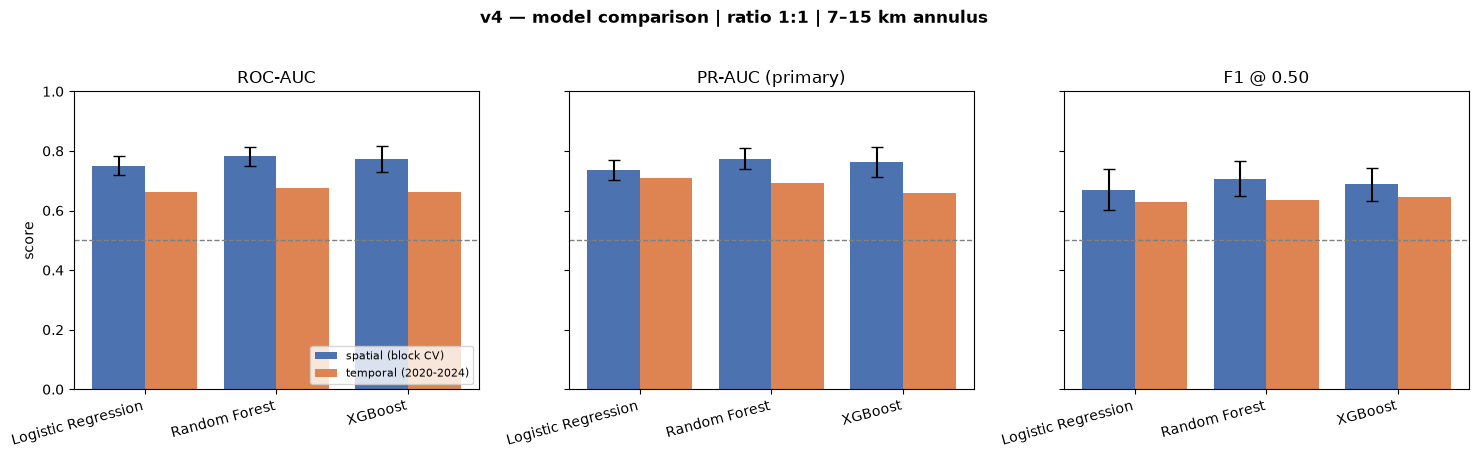

Saved: v4_model_comparison.png


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), sharey=True)
names = results["model"].tolist()
xpos = np.arange(len(names))
pairs = [("roc_auc", "ROC-AUC"), ("pr_auc", "PR-AUC (primary)"), ("f1_at_0.5", "F1 @ 0.50")]

for ax, (metric, title) in zip(axes, pairs):
    ax.bar(xpos - 0.2, results[f"spatial_{metric}"], 0.4,
           yerr=results[f"spatial_{metric}_std"], capsize=4,
           label="spatial (block CV)", color="#4c72b0")
    ax.bar(xpos + 0.2, results[f"temporal_{metric}"], 0.4,
           label=f"temporal ({TEST_START}-{TEST_END})", color="#dd8452")
    ax.axhline(0.5, ls="--", lw=1, color="grey")
    ax.set_xticks(xpos); ax.set_xticklabels(names, rotation=15, ha="right")
    ax.set_title(title); ax.set_ylim(0, 1)

axes[0].set_ylabel("score")
axes[0].legend(fontsize=8, loc="lower right")
fig.suptitle(f"v4 — model comparison | ratio 1:{RATIO} | "
             f"{INNER_BUFFER/1000:.0f}–{OUTER_BUFFER/1000:.0f} km annulus",
             fontweight="bold", y=1.03)
fig.tight_layout()
fig.savefig(VERSION_DIR / "v4_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: v4_model_comparison.png")

## 9 · Version record

A machine-readable record of every design choice, so this version is reproducible and unambiguously
distinguishable from `v1`–`v3` and XGB `v1`–`v2`.

In [27]:
record = {
    "version": "v4_buffer_7_15km",
    "created": time.strftime("%Y-%m-%d %H:%M:%S"),
    "design": {
        "ratio": f"1:{RATIO}",
        "inner_buffer_m": INNER_BUFFER,
        "outer_buffer_m": OUTER_BUFFER,
        "sampling_geometry": "annulus (ring) around same-year fire points",
        "exclusion_criterion": "per-year",
        "absence_draw": "global, unstratified (as in v3)",
        "block_degrees": BLOCK,
        "n_spatial_folds": int(n_splits),
        "seed": SEED,
        "train_years": f"<= {TRAIN_END_YEAR}",
        "test_years": f"{TEST_START}-{TEST_END}",
        "tuning_metric": "average_precision (PR-AUC)",
    },
    "predictors": list(pred_cols),
    "dataset": {
        "n_rows": int(len(model_df)),
        "n_presences": int(model_df[LABEL_COL].sum()),
        "n_absences": int((model_df[LABEL_COL] == 0).sum()),
        "n_blocks": int(model_df[GROUP_COL].nunique()),
        "eligible_in_ring": int(len(absences_ring)),
        "max_year_share_gap": float(max_gap),
    },
    "best_hyperparameters": {k: {p: str(v) for p, v in vals.items()}
                             for k, vals in best_params.items()},
}
with open(VERSION_DIR / "v4_run_record.json", "w", encoding="utf-8") as f:
    json.dump(record, f, indent=2, default=str)

print("Files written to", VERSION_DIR)
for p in sorted(VERSION_DIR.glob("v4_*")):
    print("  -", p.name)

Files written to C:\Users\Natal\CEGE0049-Wildfire-Susceptibility-Assessment-in-Sabanas-de-Yar---Bajo-Cagu-n-Colombian-Amazon\tuning\v4\v4_buffer_7_15km
  - v4_best_hyperparameters.csv
  - v4_dataset_1to1_buffer7_15km.csv
  - v4_model_comparison.png
  - v4_model_comparison_metrics.csv
  - v4_results_table.md
  - v4_ring_eligibility_by_year.csv
  - v4_run_record.json
  - v4_sampling_diagnostics.png
  - v4_spatial_cv_fold_metrics.csv
  - v4_year_balance_check.csv


## 10 · How to read the outcome

1. **Compare v4 against v3 at the same 1:1 ratio.** The only thing that changed is the sampling
   geometry, so any difference is attributable to the buffer. For reference, v3 at 1:1 gave:

   | Model | AUC esp. | PR-AUC esp. | AUC temp. | PR-AUC temp. |
   |---|---|---|---|---|
   | Logistic Regression | 0.846 | 0.823 | 0.810 | 0.747 |
   | Random Forest | 0.878 | 0.866 | 0.817 | 0.704 |
   | XGBoost | 0.871 | 0.864 | 0.811 | 0.717 |

   - *v4 metrics come in lower* → the expected and healthy result. The v3 numbers were partly
     inflated by residual spatial autocorrelation; v4 is the more honest estimate. Report v4 as the
     headline and v3 as evidence of the inflation.
   - *Metrics hold steady* → the 3 km buffer was not materially inflating performance, which is
     itself a useful robustness statement.

2. **Check whether the anthropogenic predictors recover.** This was the second motivation for the
   re-sampling. Interpretability is out of scope here, but once the final model is fixed, re-running
   the importance and distributional diagnostics on the v4 dataset will show whether the wider
   annulus restored contrast in `dist_roads` / `dist_mosaic` / `dist_coca`, or whether their weak
   showing is a genuine scale-dependent finding worth writing up as a result.

3. **Select the model for the susceptibility map** on **PR-AUC**, weighting temporal performance most
   heavily — the operational use case is forecasting a future season, which is what the 2020–2024
   holdout simulates.

**Then:** fix the winning model, predict across the full nucleus, reclassify into the
1–40 / 41–60 / 61–80 / 81–100 susceptibility bins, and carry that surface into Objective 2
(socio-ecological exposure overlay) and Objective 3 (carbon at risk).